# 📰 Phase 6: NER, Visualisasi & Analisis — LPDP

---

## 🎯 Tujuan Notebook
Melakukan **Named Entity Recognition (NER)**, **visualisasi komprehensif**, dan **analisis mendalam** dari dataset artikel LPDP yang sudah melalui pipeline preprocessing dan feature extraction.

### Alur Proses:
| Langkah | Deskripsi |
|---------|----------|
| 1️⃣ Load Dataset | Muat hasil Phase 4 & 5 (`dataset_lpdp_preprocessed.csv`) |
| 2️⃣ NER | Ekstrak entitas (Person, Organization, Location, dll.) via `indobert-base-ner` |
| 3️⃣ Analisis NER | Frekuensi entitas per kategori, per sentimen, per topik |
| 4️⃣ Visualisasi Sentimen | Distribusi sentimen (overall, per topik, per waktu) |
| 5️⃣ Visualisasi Topik | Word cloud, TF-IDF top terms per topik |
| 6️⃣ Analisis Temporal | Tren sentimen & topik berdasarkan tanggal artikel |
| 7️⃣ Analisis Per Sumber | Sentimen & topik per media/sumber berita |
| 8️⃣ Export | Simpan hasil NER + ringkasan analisis ke Excel & gambar |

---

**Kelompok 5:** Amel, Celine, Iqbal, Nida, Salwa

**PIC Phase 6:** Nida

**Input:**
- `dataset_lpdp_preprocessed.csv` — 1.038 artikel + `text_clean`, `Sentiment`, `topic_label` (Phase 4 output)
- `output_bertopic/bertopic_4_topik_final.xlsx` — artikel dengan label topik final (Phase 3 output)

**Output Folder:** `output_ner_visualisasi/`
- `ner_results.csv` — hasil NER per artikel
- `ner_entities_summary.xlsx` — ringkasan entitas per tipe
- `*.png` — semua grafik visualisasi

## 📦 Install Dependencies

In [1]:
import sys, subprocess

packages = [
    "transformers",
    "torch",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "wordcloud",
    "openpyxl",
    "tqdm",
    "scikit-learn",
    "Sastrawi",
    "nltk",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])
print("✅ Semua package berhasil diinstall!")

✅ Semua package berhasil diinstall!



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python3 -m pip install --upgrade pip


## 📦 Import Libraries

In [2]:
# === Standard Library ===
import os
import re
import json
import warnings
from pathlib import Path
from collections import Counter, defaultdict

# === Data Manipulation ===
import pandas as pd
import numpy as np

# === NLP ===
import torch
from transformers import pipeline, AutoTokenizer, AutoModelForTokenClassification
from tqdm.auto import tqdm
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# === Visualization ===
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

# === Settings ===
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

DEVICE = 0 if torch.cuda.is_available() else -1  # GPU jika tersedia
print(f"✅ Semua library berhasil diimport!")
print(f"   Device NER : {'GPU (cuda)' if DEVICE == 0 else 'CPU'}")
print(f"   pandas     : {pd.__version__}")
print(f"   torch      : {torch.__version__}")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1006)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1006)>


✅ Semua library berhasil diimport!
   Device NER : CPU
   pandas     : 2.3.0
   torch      : 2.11.0


## 📂 Load Dataset & Setup Output Folder

In [3]:
# === Path Konfigurasi ===
PREPROCESSED_FILE = "dataset_lpdp_preprocessed.csv"
OUTPUT_DIR = Path("output_ner_visualisasi")
OUTPUT_DIR.mkdir(exist_ok=True)

# === Load Dataset ===
df = pd.read_csv(PREPROCESSED_FILE)
print(f"📂 Dataset dimuat: {PREPROCESSED_FILE}")
print(f"   Shape  : {df.shape}")
print(f"   Kolom  : {df.columns.tolist()}")

# === Gunakan label_name sebagai topic_label ===
df['topic_label'] = df['label_name']

# === Kolom konten untuk NER (pakai Content asli, bukan text_clean yang sudah di-stem) ===
content_col = 'Content'

print(f"\n📊 Distribusi Sentimen:")
print(df['Sentiment'].value_counts())
print(f"\n📊 Distribusi Topik:")
print(df['topic_label'].value_counts(dropna=False))

📂 Dataset dimuat: dataset_lpdp_preprocessed.csv
   Shape  : (1038, 14)
   Kolom  : ['doc_id', 'Title', 'Release Date', 'URL', 'Publisher', 'PiC', 'Valid?', 'Sentiment', 'Notes', 'Actual_URL', 'Content', 'label_4', 'label_name', 'text_clean']

📊 Distribusi Sentimen:
Sentiment
Positive    385
Neutral     342
Negative    311
Name: count, dtype: int64

📊 Distribusi Topik:
topic_label
Kebijakan & Prioritas Program    553
Kewajiban & Sanksi Penerima      147
Pendaftaran & Seleksi LPDP       140
NaN                              101
Kontroversi Penerima Beasiswa     97
Name: count, dtype: int64


---
## 🏷️ Part 1: Named Entity Recognition (NER)

### 1.1 Setup NER Pipeline

Menggunakan model **`cahya/bert-base-indonesian-NER`** — BERT yang di-fine-tune khusus untuk NER Bahasa Indonesia.

| Tipe Entitas | Label | Contoh |
|---|---|---|
| Person | PER | Jokowi, Menteri Sri Mulyani |
| Organization | ORG | LPDP, Kemenkeu, UI |
| Location | LOC | Jakarta, Indonesia, Jepang |
| Quantity | QTY | 5.000 penerima, Rp 300 juta |

In [4]:
# === Load NER Model ===
NER_MODEL = "cahya/bert-base-indonesian-NER"
print(f"📥 Memuat model NER: {NER_MODEL}")
print("   (Proses ini memerlukan koneksi internet dan beberapa menit di CPU)")

ner_pipeline = pipeline(
    task="ner",
    model=NER_MODEL,
    aggregation_strategy="simple",   # Gabung sub-token entitas yang sama
    device=DEVICE,
)

print(f"✅ Model NER berhasil dimuat!")

📥 Memuat model NER: cahya/bert-base-indonesian-NER
   (Proses ini memerlukan koneksi internet dan beberapa menit di CPU)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 37223.68it/s]
[transformers] BertForTokenClassification LOAD REPORT from: cahya/bert-base-indonesian-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model NER berhasil dimuat!


### 1.2 Jalankan NER pada Seluruh Artikel

> ⏱️ **Estimasi waktu**: ~5–15 menit di CPU, ~1–3 menit di GPU.  
> Notebook ini akan **menyimpan progress** ke `output_ner_visualisasi/ner_results.csv` setiap 50 artikel — aman jika terputus.

In [5]:
NER_OUTPUT_FILE = OUTPUT_DIR / "ner_results.csv"
SAVE_EVERY = 50

# Potong teks manual sebelum masuk pipeline (hindari truncation error)
def truncate_text(text, max_tokens=400):
    """Potong teks ke max_tokens kata — aman untuk BERT 512 token limit."""
    words = str(text).split()
    return ' '.join(words[:max_tokens])

# === Hapus file kosong jika ada ===
if NER_OUTPUT_FILE.exists() and NER_OUTPUT_FILE.stat().st_size < 10:
    NER_OUTPUT_FILE.unlink()
    print("🗑️ File kosong dihapus, mulai dari awal.")

# === Resume dari checkpoint jika ada ===
if NER_OUTPUT_FILE.exists():
    df_ner_done = pd.read_csv(NER_OUTPUT_FILE)
    done_ids = set(df_ner_done['doc_id'].tolist())
    print(f"⏩ Resume: {len(done_ids)} artikel sudah selesai.")
else:
    df_ner_done = pd.DataFrame()
    done_ids = set()

# === Test dulu ===
print("\n🧪 Test NER pada artikel pertama...")
sample_text = truncate_text(df[content_col].iloc[0])
try:
    test_result = ner_pipeline(sample_text)
    print(f"✅ NER berjalan! Entitas ditemukan: {len(test_result)}")
    for e in test_result[:5]:
        print(f"   {e['word']:<25} → {e['entity_group']} ({e['score']:.2f})")
except Exception as e:
    print(f"❌ NER gagal: {e}")
    raise

# === Loop NER semua artikel ===
df_todo = df[~df['doc_id'].isin(done_ids)].reset_index(drop=True)
print(f"\n📋 Artikel yang akan diproses: {len(df_todo)} dari {len(df)} total")

results = []
for i, row in tqdm(df_todo.iterrows(), total=len(df_todo), desc="NER Progress"):
    text = truncate_text(row[content_col])
    try:
        entities = ner_pipeline(text)
    except Exception:
        entities = []

    for ent in entities:
        results.append({
            'doc_id'      : row['doc_id'],
            'Sentiment'   : row.get('Sentiment'),
            'topic_label' : row.get('topic_label'),
            'entity'      : ent['word'].strip(),
            'entity_type' : ent['entity_group'],
            'score'       : round(ent['score'], 4),
        })

    # Simpan checkpoint
    if (i + 1) % SAVE_EVERY == 0 or (i + 1) == len(df_todo):
        df_batch = pd.DataFrame(results)
        df_all_ner = pd.concat([df_ner_done, df_batch], ignore_index=True)
        df_all_ner.to_csv(NER_OUTPUT_FILE, index=False)

# === Load hasil final ===
df_ner = pd.read_csv(NER_OUTPUT_FILE)
print(f"\n✅ NER selesai!")
print(f"   Total entitas ditemukan : {len(df_ner)}")
print(f"   Total artikel diproses  : {df_ner['doc_id'].nunique()}")
df_ner.head(10)


🧪 Test NER pada artikel pertama...
✅ NER berjalan! Entitas ditemukan: 72
   lpdp                      → ORG (0.47)
   jakarta                   → GPE (0.75)
   antara                    → ORG (0.82)
   sekretaris komisi e dprd dki jakarta → NOR (0.96)
   justin adrian untayana    → PER (0.99)

📋 Artikel yang akan diproses: 1038 dari 1038 total


NER Progress: 100%|██████████| 1038/1038 [01:26<00:00, 11.96it/s]


✅ NER selesai!
   Total entitas ditemukan : 32202
   Total artikel diproses  : 643


,doc_id,Sentiment,topic_label,entity,entity_type,score
0,0,Negative,Kebijakan & Prioritas Program,lpdp,ORG,0.4684
1,0,Negative,Kebijakan & Prioritas Program,jakarta,GPE,0.7513
2,0,Negative,Kebijakan & Prioritas Program,antara,ORG,0.8159
3,0,Negative,Kebijakan & Prioritas Program,sekretaris komisi e dprd dki jakarta,NOR,0.9575
4,0,Negative,Kebijakan & Prioritas Program,justin adrian untayana,PER,0.9865
5,0,Negative,Kebijakan & Prioritas Program,lembaga pengelola dana pendidikan,ORG,0.8939
6,0,Negative,Kebijakan & Prioritas Program,lpdp,ORG,0.8261
7,0,Negative,Kebijakan & Prioritas Program,jakarta,GPE,0.9743
8,0,Negative,Kebijakan & Prioritas Program,justin,PER,0.9971
9,0,Negative,Kebijakan & Prioritas Program,jakarta,GPE,0.9974


### 1.3 Analisis Frekuensi Entitas

In [6]:
# === Filter confidence tinggi ===
df_ner_filtered = df_ner[df_ner['score'] >= 0.85].copy()
print(f"📊 Entitas dengan score ≥ 0.85 : {len(df_ner_filtered)} dari {len(df_ner)} total")

# === Summary per tipe entitas ===
entity_types = df_ner_filtered['entity_type'].unique()
print(f"\n🏷️  Tipe entitas ditemukan: {sorted(entity_types)}")

print("\n📋 Top 15 Entitas per Tipe:")
entity_summaries = {}
for etype in sorted(entity_types):
    top = (
        df_ner_filtered[df_ner_filtered['entity_type'] == etype]
        .groupby('entity')['doc_id']
        .nunique()
        .sort_values(ascending=False)
        .head(20)
        .reset_index()
        .rename(columns={'doc_id': 'jumlah_artikel'})
    )
    top['entity_type'] = etype
    entity_summaries[etype] = top
    print(f"\n   [{etype}]")
    print(top.head(10).to_string(index=False))

# === Simpan ke Excel (multi-sheet) ===
summary_path = OUTPUT_DIR / "ner_entities_summary.xlsx"
with pd.ExcelWriter(summary_path, engine='openpyxl') as writer:
    df_ner_filtered.to_excel(writer, sheet_name='All_Entities', index=False)
    for etype, summary_df in entity_summaries.items():
        summary_df.to_excel(writer, sheet_name=f'Top_{etype}', index=False)
print(f"\n💾 Tersimpan: {summary_path}")

📊 Entitas dengan score ≥ 0.85 : 6859 dari 32202 total

🏷️  Tipe entitas ditemukan: ['CRD', 'DAT', 'EVT', 'GPE', 'LAW', 'LOC', 'MON', 'NOR', 'ORD', 'ORG', 'PER', 'PRC', 'PRD', 'QTY', 'REG', 'TIM']

📋 Top 15 Entitas per Tipe:

   [CRD]
 entity  jumlah_artikel entity_type
    dua              98         CRD
   satu              57         CRD
      2              45         CRD
   tiga              42         CRD
  empat              28         CRD
   lima              24         CRD
delapan              17         CRD
     36              14         CRD
      3              14         CRD
      1              10         CRD

   [DAT]
                 entity  jumlah_artikel entity_type
                   2025              35         DAT
                   2024              23         DAT
                   2023              17         DAT
                   2017              15         DAT
                   2016              12         DAT
                   2013              11         

---
## 📊 Part 2: Visualisasi Sentimen

### 2.1 Distribusi Sentimen Overall

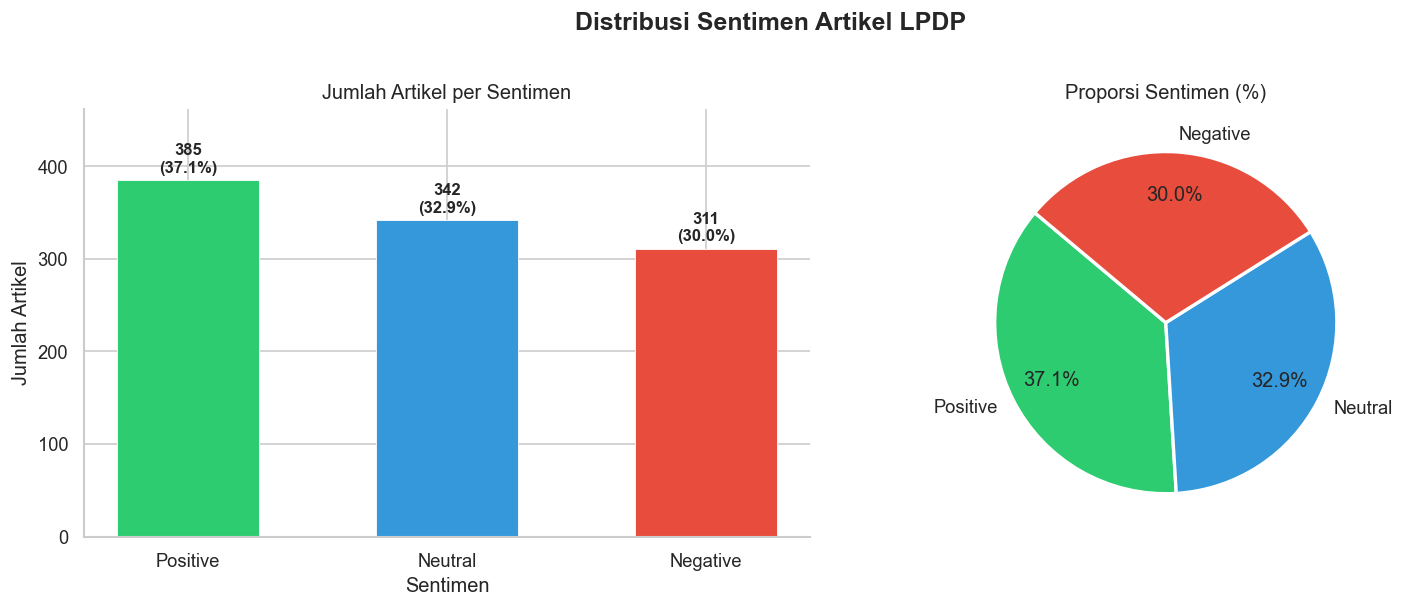

💾 Disimpan: output_ner_visualisasi/sentiment_distribusi_overall.png


In [7]:
PALETTE = {'Positive': '#2ecc71', 'Neutral': '#3498db', 'Negative': '#e74c3c'}
sentiment_counts = df['Sentiment'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribusi Sentimen Artikel LPDP', fontsize=15, fontweight='bold', y=1.01)

# --- Bar chart ---
bars = axes[0].bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=[PALETTE.get(s, 'gray') for s in sentiment_counts.index],
    edgecolor='white', linewidth=0.5, width=0.55
)
for bar, val in zip(bars, sentiment_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Jumlah Artikel per Sentimen', fontsize=12)
axes[0].set_xlabel('Sentimen')
axes[0].set_ylabel('Jumlah Artikel')
axes[0].set_ylim(0, sentiment_counts.max() * 1.2)
axes[0].spines[['top', 'right']].set_visible(False)

# --- Pie chart ---
axes[1].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    colors=[PALETTE.get(s, 'gray') for s in sentiment_counts.index],
    autopct='%1.1f%%', startangle=140,
    pctdistance=0.75, labeldistance=1.1,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporsi Sentimen (%)', fontsize=12)

plt.tight_layout()
out_path = OUTPUT_DIR / 'sentiment_distribusi_overall.png'
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f"💾 Disimpan: {out_path}")

### 2.2 Sentimen per Topik

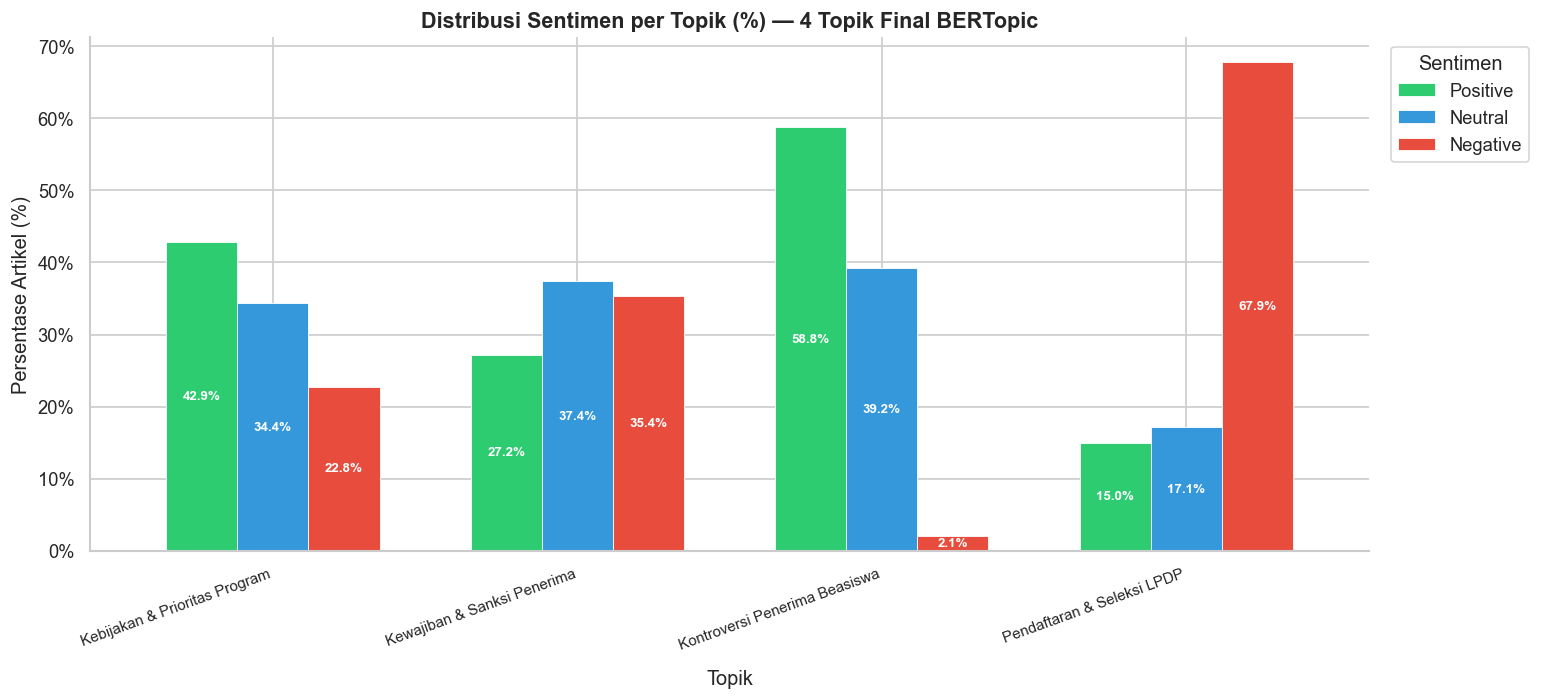

💾 Disimpan: output_ner_visualisasi/sentiment_per_topik.png


In [8]:
df_valid_topic = df.dropna(subset=['topic_label'])

pivot = (
    df_valid_topic.groupby(['topic_label', 'Sentiment'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['Positive', 'Neutral', 'Negative'], fill_value=0)
)

# Normalisasi ke persen
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 6))
pivot_pct.plot(
    kind='bar',
    color=[PALETTE.get(c, 'gray') for c in pivot_pct.columns],
    ax=ax, edgecolor='white', linewidth=0.5, width=0.7
)

ax.set_title('Distribusi Sentimen per Topik (%) — 4 Topik Final BERTopic', fontsize=13, fontweight='bold')
ax.set_xlabel('Topik', labelpad=10)
ax.set_ylabel('Persentase Artikel (%)')
ax.set_xticklabels(pivot_pct.index, rotation=20, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title='Sentimen', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

# Anotasi nilai
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
out_path = OUTPUT_DIR / 'sentiment_per_topik.png'
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f"💾 Disimpan: {out_path}")

### 2.3 Tren Sentimen per Waktu (Bulanan)

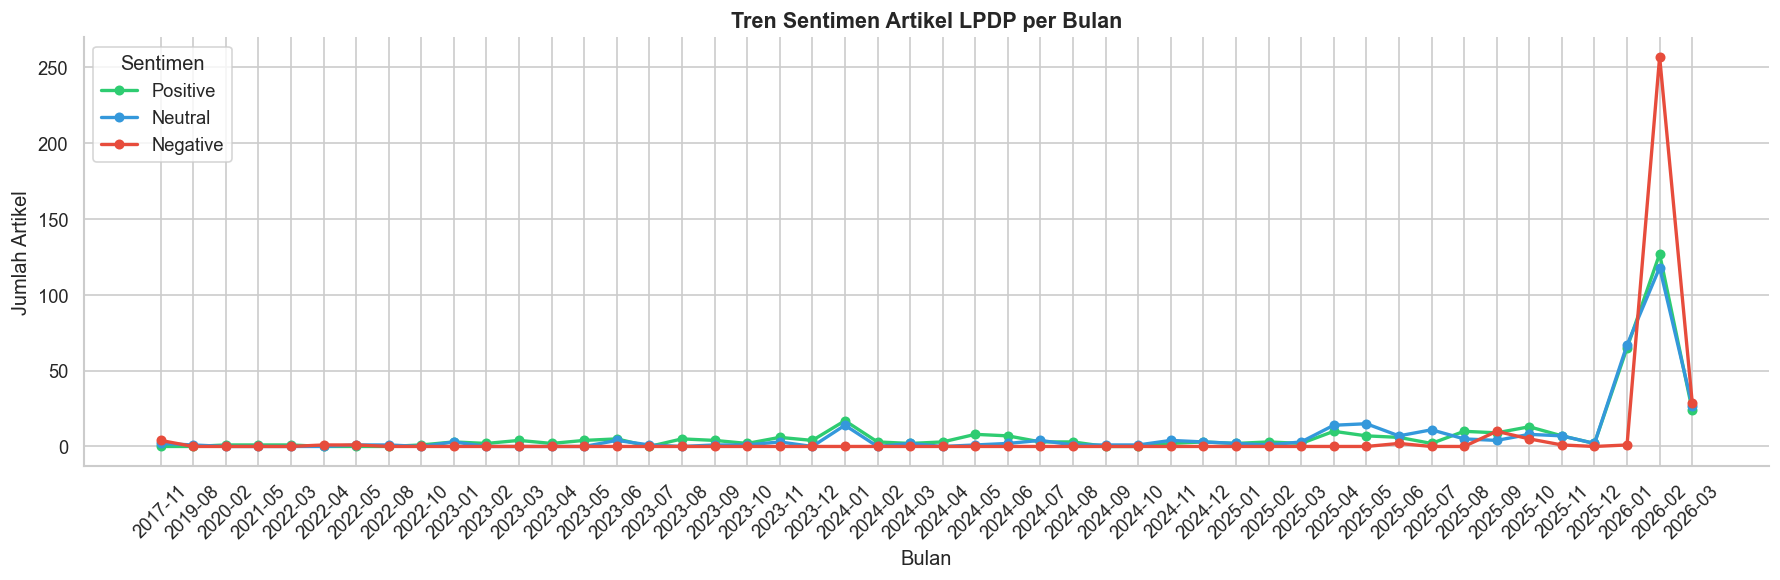

💾 Disimpan: output_ner_visualisasi/sentiment_trend_bulanan.png


In [9]:
# Deteksi kolom tanggal
date_col = None
for c in ['Release Date','published_date', 'Tanggal', 'date', 'Date', 'publish_date', 'Tanggal Rilis']:
    if c in df.columns:
        date_col = c
        break

if date_col:
    df['date_parsed'] = pd.to_datetime(df[date_col], errors='coerce')
    df['year_month'] = df['date_parsed'].dt.to_period('M').astype(str)

    trend = (
        df.dropna(subset=['year_month'])
        .groupby(['year_month', 'Sentiment'])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(15, 5))
    for sentiment in ['Positive', 'Neutral', 'Negative']:
        if sentiment in trend.columns:
            ax.plot(trend.index, trend[sentiment], marker='o', markersize=5,
                    label=sentiment, color=PALETTE[sentiment], linewidth=2)

    ax.set_title('Tren Sentimen Artikel LPDP per Bulan', fontsize=13, fontweight='bold')
    ax.set_xlabel('Bulan')
    ax.set_ylabel('Jumlah Artikel')
    ax.xaxis.set_tick_params(rotation=45)
    ax.legend(title='Sentimen')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    out_path = OUTPUT_DIR / 'sentiment_trend_bulanan.png'
    plt.savefig(out_path, bbox_inches='tight')
    plt.show()
    print(f"💾 Disimpan: {out_path}")
else:
    print("⚠️ Kolom tanggal tidak ditemukan. Visualisasi tren temporal dilewati.")
    print(f"   Kolom yang tersedia: {df.columns.tolist()}")

---
## 📊 Part 3: Visualisasi Topik & Word Cloud

### 3.1 Word Cloud per Topik

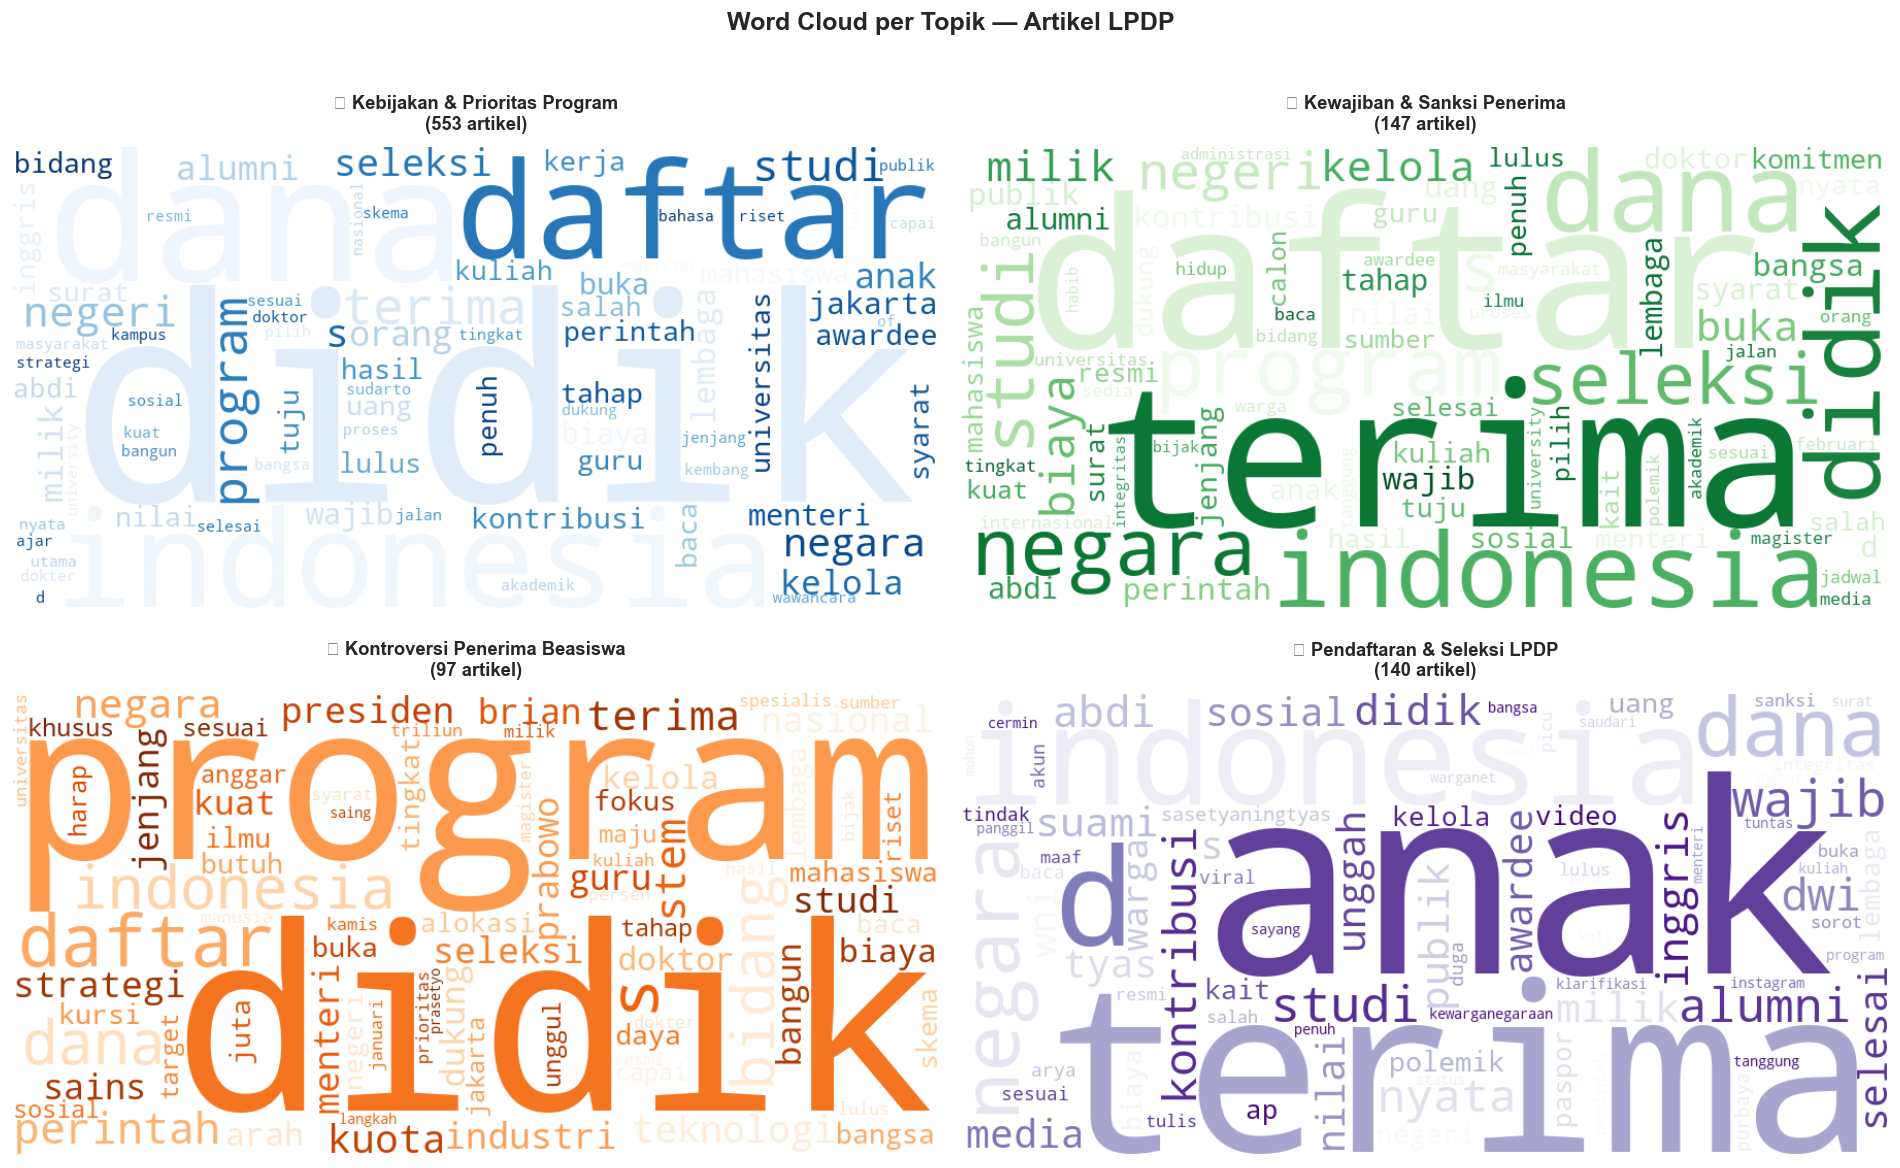

💾 Disimpan: output_ner_visualisasi/wordcloud_per_topik.png


In [10]:
from nltk.corpus import stopwords as nltk_stopwords

# Stopword Bahasa Indonesia
try:
    id_stopwords = set(nltk_stopwords.words('indonesian'))
except:
    id_stopwords = set()

# Tambahan stopword spesifik domain LPDP
extra_stopwords = {
    'lpdp', 'beasiswa', 'artikel', 'kata', 'juga', 'sudah',
    'bisa', 'dari', 'untuk', 'yang', 'dengan', 'pada', 'ini',
    'tersebut', 'akan', 'karena', 'saat', 'para', 'oleh',
    'namun', 'serta', 'itu', 'nya', 'an', 'ke', 'di', 'dan',
}
all_stopwords = id_stopwords | extra_stopwords

topics = df_valid_topic['topic_label'].unique()
n_topics = len(topics)
ncols = 2
nrows = (n_topics + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes = axes.flatten() if n_topics > 1 else [axes]

TOPIC_COLORS = [
    'Blues', 'Greens', 'Oranges', 'Purples', 'Reds', 'YlOrBr'
]

for idx, topic in enumerate(sorted(topics)):
    subset = df_valid_topic[df_valid_topic['topic_label'] == topic]
    all_text = ' '.join(subset['text_clean'].dropna().astype(str).tolist())
    
    wc = WordCloud(
        width=900, height=450,
        background_color='white',
        colormap=TOPIC_COLORS[idx % len(TOPIC_COLORS)],
        max_words=80,
        stopwords=all_stopwords,
        collocations=False,
        min_font_size=10,
    ).generate(all_text)
    
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(f"📌 {topic}\n({len(subset)} artikel)",
                        fontsize=11, fontweight='bold', pad=10)
    axes[idx].axis('off')

# Sembunyikan subplot kosong
for j in range(n_topics, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Word Cloud per Topik — Artikel LPDP', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
out_path = OUTPUT_DIR / 'wordcloud_per_topik.png'
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f"💾 Disimpan: {out_path}")

### 3.2 Top TF-IDF Terms per Topik

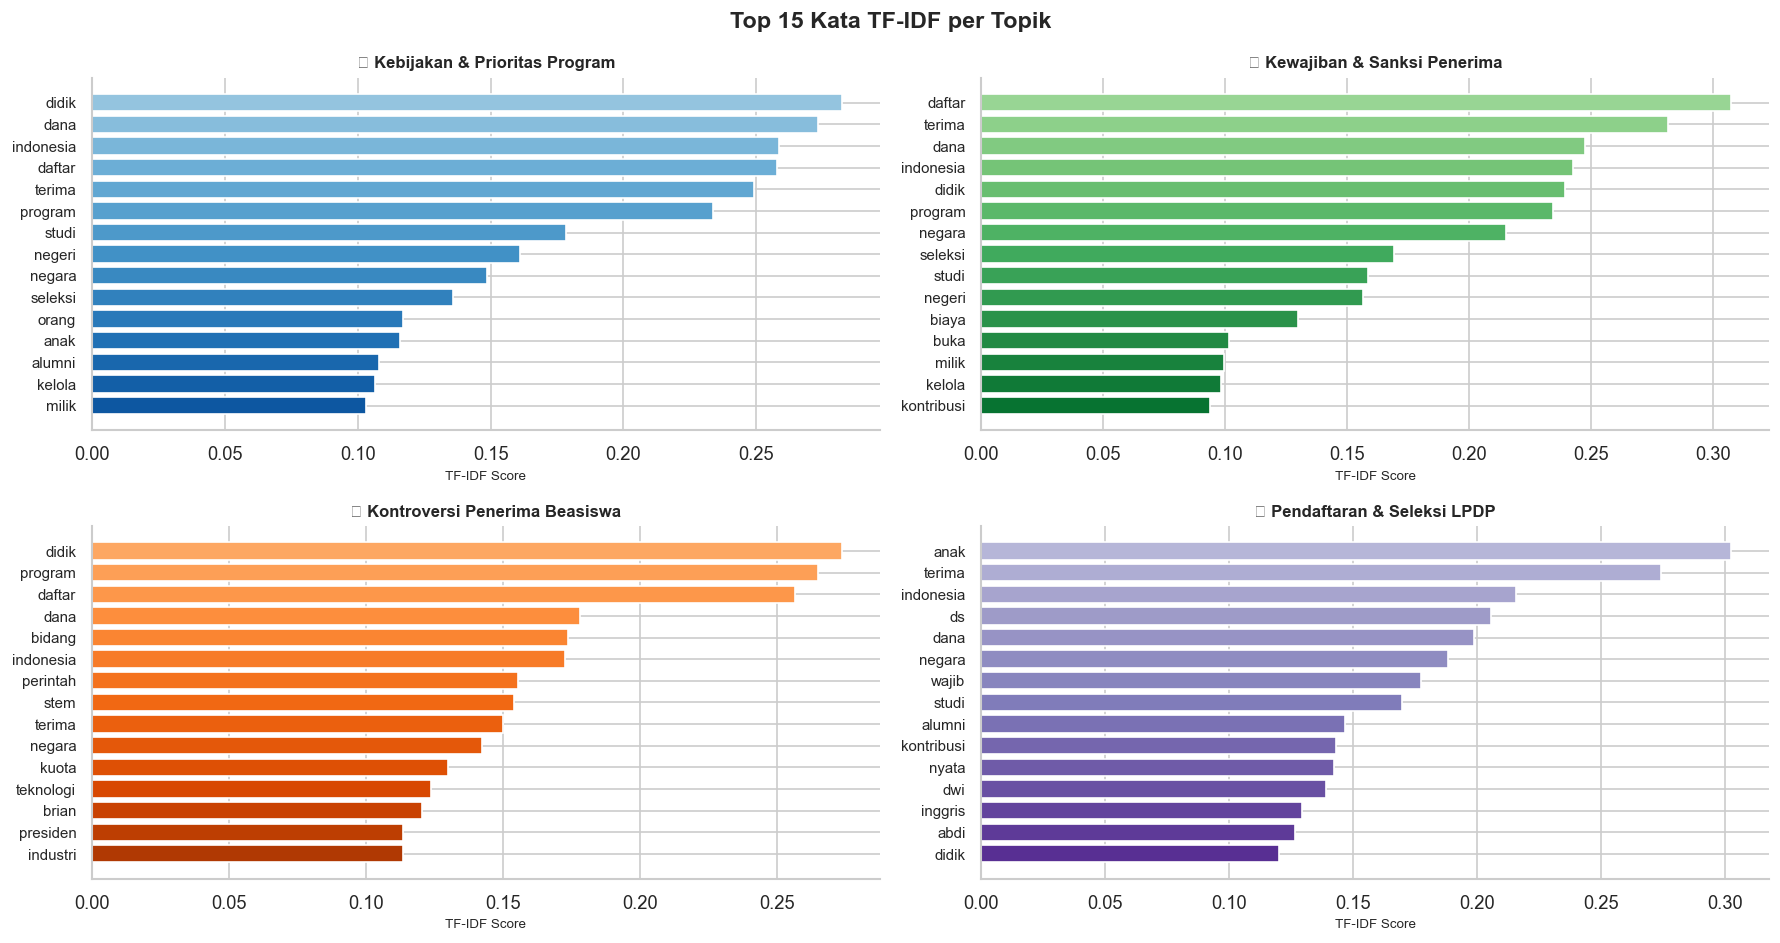

💾 Disimpan: output_ner_visualisasi/tfidf_top_terms_per_topik.png


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

TOP_N = 15  # Jumlah kata teratas per topik

# Buat corpus per topik (gabungkan semua artikel dalam satu topik)
topic_corpus = (
    df_valid_topic.groupby('topic_label')['text_clean']
    .apply(lambda texts: ' '.join(texts.dropna().astype(str)))
    .reset_index()
)

tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    stop_words=list(all_stopwords),
    min_df=1
)
X = tfidf.fit_transform(topic_corpus['text_clean'])
feature_names = tfidf.get_feature_names_out()

n_topics = len(topic_corpus)
ncols = 2
nrows = (n_topics + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten() if n_topics > 1 else [axes]

for i, (row, ax) in enumerate(zip(topic_corpus.itertuples(), axes)):
    scores = X[i].toarray().flatten()
    top_idx = np.argsort(scores)[::-1][:TOP_N]
    top_words = [feature_names[j] for j in top_idx]
    top_scores = [scores[j] for j in top_idx]
    
    # Horizontal bar
    colors = plt.cm.get_cmap(TOPIC_COLORS[i % len(TOPIC_COLORS)])(np.linspace(0.4, 0.85, TOP_N))
    ax.barh(range(TOP_N), top_scores[::-1], color=colors[::-1], edgecolor='white')
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_words[::-1], fontsize=9)
    ax.set_title(f"📌 {row.topic_label}", fontsize=10, fontweight='bold')
    ax.set_xlabel('TF-IDF Score', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

for j in range(n_topics, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'Top {TOP_N} Kata TF-IDF per Topik', fontsize=14, fontweight='bold')
plt.tight_layout()
out_path = OUTPUT_DIR / 'tfidf_top_terms_per_topik.png'
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f"💾 Disimpan: {out_path}")

---
## 📊 Part 4: Visualisasi NER

### 4.1 Top Entitas per Tipe (Bar Chart)

Tipe entitas setelah filter: ['LOC', 'NOR', 'ORG', 'PER']
Total entitas: 2449 (dari 6859 sebelumnya)


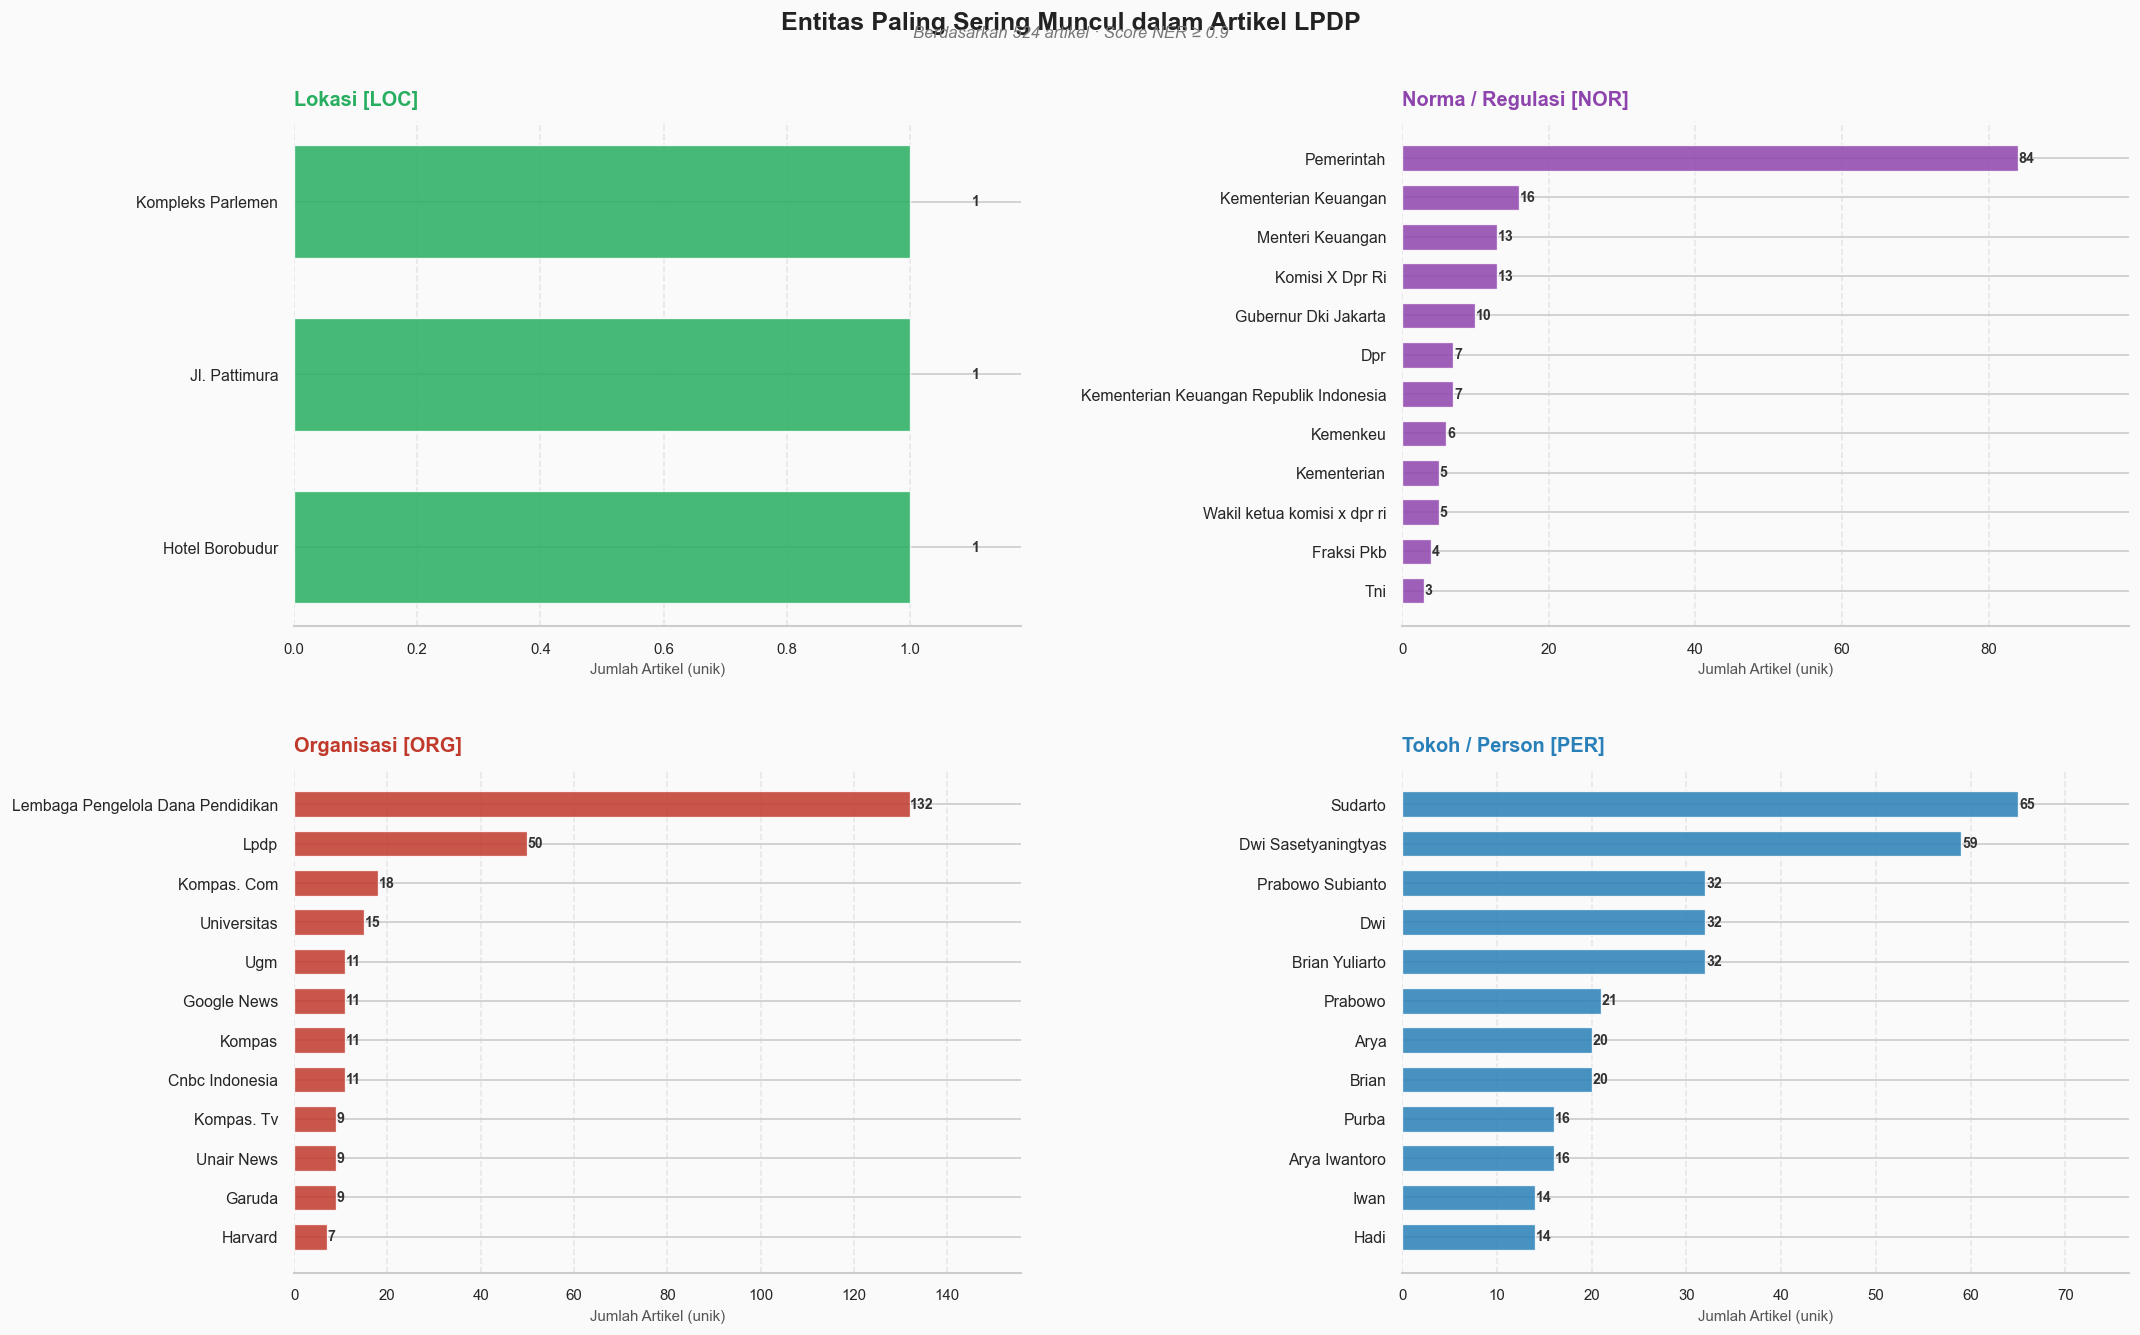

💾 Disimpan: output_ner_visualisasi/ner_top_entities_per_tipe.png


In [12]:
# === Konfigurasi ===
TOP_ENT = 12
SCORE_THRESHOLD = 0.90  # Naikkan threshold untuk kurangi noise

# Blacklist entitas noise
# BLACKLIST = {
#     'rp', 'triliun', 'miliar', 'juta', 'ribu',          # MON duplikat
#     'hotel borobudur', 'pasar minggu', 'jl. pattimura',  # LOC tidak relevan
#     'pancasila', 'uud 1945',                              # LAW terlalu umum
#     '%', '-', '/', '.',
# }

def clean_entity(text):
    """Normalisasi entitas: strip, lowercase, hapus spasi ganda."""
    return re.sub(r'\s+', ' ', text.strip().lower())

# Re-filter dengan threshold lebih tinggi + blacklist
df_ner_clean = df_ner[df_ner['score'] >= SCORE_THRESHOLD].copy()
df_ner_clean['entity'] = df_ner_clean['entity'].apply(clean_entity)
# df_ner_clean = df_ner_clean[~df_ner_clean['entity'].isin(BLACKLIST)]
df_ner_clean = df_ner_clean[df_ner_clean['entity'].str.len() >= 3]  # Hapus entitas < 3 karakter

# Fokus hanya tipe entitas yang relevan
RELEVANT_TYPES = ['PER', 'ORG', 'LOC', 'NOR']
df_ner_clean = df_ner_clean[df_ner_clean['entity_type'].isin(RELEVANT_TYPES)]

entity_types_plot = sorted(df_ner_clean['entity_type'].unique())
print(f"Tipe entitas setelah filter: {entity_types_plot}")
print(f"Total entitas: {len(df_ner_clean)} (dari {len(df_ner_filtered)} sebelumnya)")

# === Warna & Label per tipe ===
TYPE_CONFIG = {
    'PER': {'color': '#2980b9', 'label': 'Tokoh / Person'},
    'ORG': {'color': '#c0392b', 'label': 'Organisasi'},
    'LOC': {'color': '#27ae60', 'label': 'Lokasi'},
    'NOR': {'color': '#8e44ad', 'label': 'Norma / Regulasi'},
    'QTY': {'color': '#e67e22', 'label': 'Kuantitas'},
    'EVT': {'color': '#16a085', 'label': 'Event'},
}

# === Plot ===
ncols = 2
nrows = (len(entity_types_plot) + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5.5 * nrows))
fig.patch.set_facecolor('#fafafa')
axes = axes.flatten() if len(entity_types_plot) > 1 else [axes]

for idx, etype in enumerate(entity_types_plot):
    ax = axes[idx]
    cfg = TYPE_CONFIG.get(etype, {'color': '#95a5a6', 'label': etype})

    top_ent = (
        df_ner_clean[df_ner_clean['entity_type'] == etype]
        .groupby('entity')['doc_id'].nunique()
        .sort_values(ascending=False)
        .head(TOP_ENT)
        .sort_values(ascending=True)  # ascending untuk barh (bawah = terkecil)
    )

    # Capitalize label entitas
    labels = [e.title() if len(e.split()) <= 4 else e.capitalize() for e in top_ent.index]

    bars = ax.barh(
        labels, top_ent.values,
        color=cfg['color'], alpha=0.85,
        edgecolor='white', linewidth=0.8,
        height=0.65
    )

    # Anotasi nilai di ujung bar
    for bar, val in zip(bars, top_ent.values):
        ax.text(
            bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', ha='left', fontsize=8.5,
            color='#333333', fontweight='bold'
        )

    # Styling
    ax.set_facecolor('#fafafa')
    ax.set_title(
        f"{cfg['label']} [{etype}]",
        fontsize=12, fontweight='bold',
        color=cfg['color'], pad=10, loc='left'
    )
    ax.set_xlabel('Jumlah Artikel (unik)', fontsize=9, color='#555')
    ax.tick_params(axis='y', labelsize=9.5)
    ax.tick_params(axis='x', labelsize=9)
    ax.set_xlim(0, top_ent.values.max() * 1.18)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4, color='#ccc')
    ax.set_axisbelow(True)

# Sembunyikan subplot kosong
for j in range(len(entity_types_plot), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Entitas Paling Sering Muncul dalam Artikel LPDP',
    fontsize=15, fontweight='bold', color='#222', y=1.01
)
fig.text(
    0.5, 0.99,
    f'Berdasarkan {df_ner_clean["doc_id"].nunique()} artikel · Score NER ≥ {SCORE_THRESHOLD}',
    ha='center', fontsize=10, color='#777', style='italic'
)

plt.tight_layout(h_pad=3, w_pad=3)
out_path = OUTPUT_DIR / 'ner_top_entities_per_tipe.png'
plt.savefig(out_path, bbox_inches='tight', dpi=150, facecolor='#fafafa')
plt.show()
print(f"💾 Disimpan: {out_path}")

### 4.2 Entitas ORG & PER per Sentimen (Heatmap)

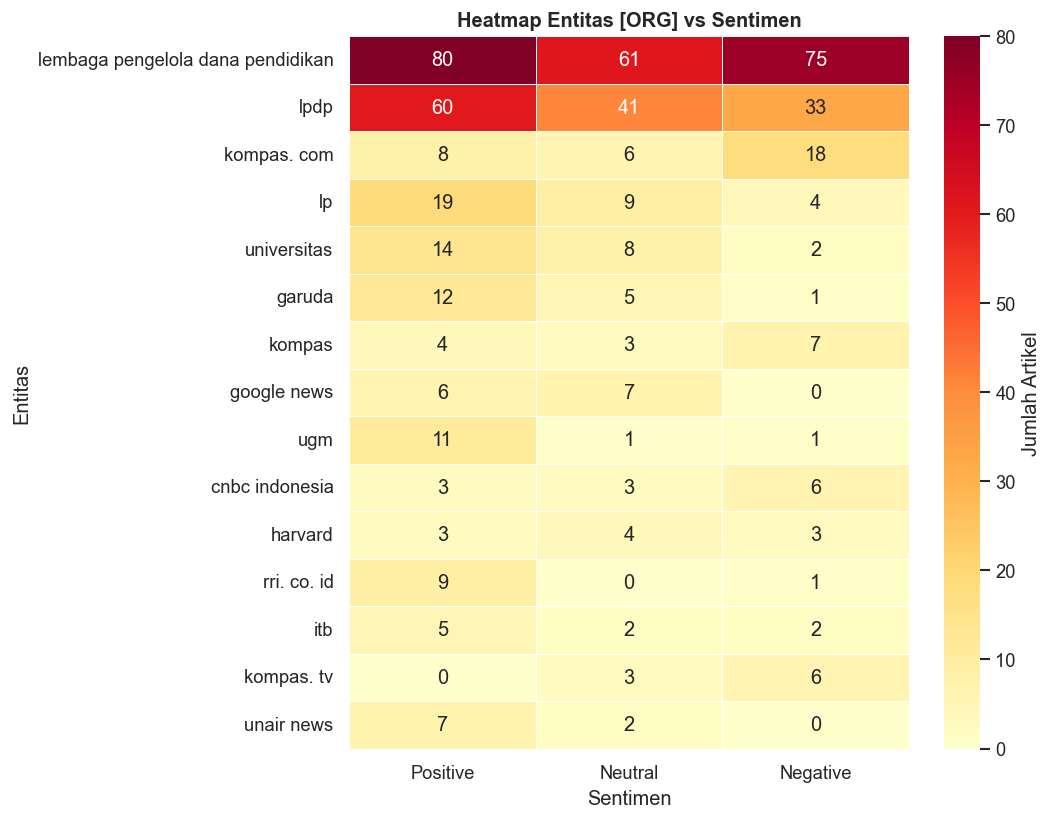

💾 Disimpan: output_ner_visualisasi/ner_heatmap_ORG_sentimen.png


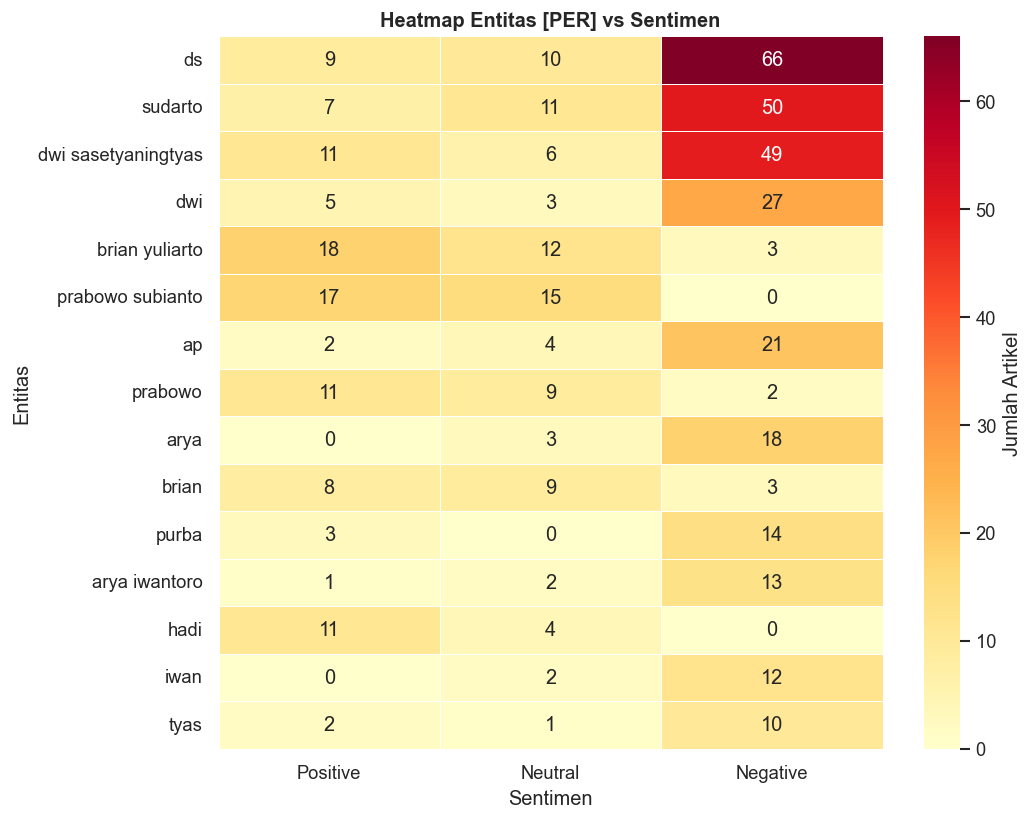

💾 Disimpan: output_ner_visualisasi/ner_heatmap_PER_sentimen.png


In [13]:
for etype in ['ORG', 'PER']:
    if etype not in df_ner_filtered['entity_type'].values:
        print(f"⚠️ Entitas tipe '{etype}' tidak ditemukan, dilewati.")
        continue

    top_entities = (
        df_ner_filtered[df_ner_filtered['entity_type'] == etype]
        .groupby('entity')['doc_id'].nunique()
        .sort_values(ascending=False)
        .head(15).index.tolist()
    )

    heat_data = (
        df_ner_filtered[
            (df_ner_filtered['entity_type'] == etype) &
            (df_ner_filtered['entity'].isin(top_entities))
        ]
        .groupby(['entity', 'Sentiment'])['doc_id'].nunique()
        .unstack(fill_value=0)
        .reindex(columns=['Positive', 'Neutral', 'Negative'], fill_value=0)
    )

    # Urutkan berdasarkan total
    heat_data['_total'] = heat_data.sum(axis=1)
    heat_data = heat_data.sort_values('_total', ascending=False).drop(columns='_total')

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(
        heat_data,
        annot=True, fmt='d', cmap='YlOrRd',
        linewidths=0.5, linecolor='white',
        ax=ax, cbar_kws={'label': 'Jumlah Artikel'}
    )
    ax.set_title(f'Heatmap Entitas [{etype}] vs Sentimen', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sentimen')
    ax.set_ylabel('Entitas')
    plt.tight_layout()
    out_path = OUTPUT_DIR / f'ner_heatmap_{etype}_sentimen.png'
    plt.savefig(out_path, bbox_inches='tight')
    plt.show()
    print(f"💾 Disimpan: {out_path}")

### 4.3 Entitas ORG per Topik

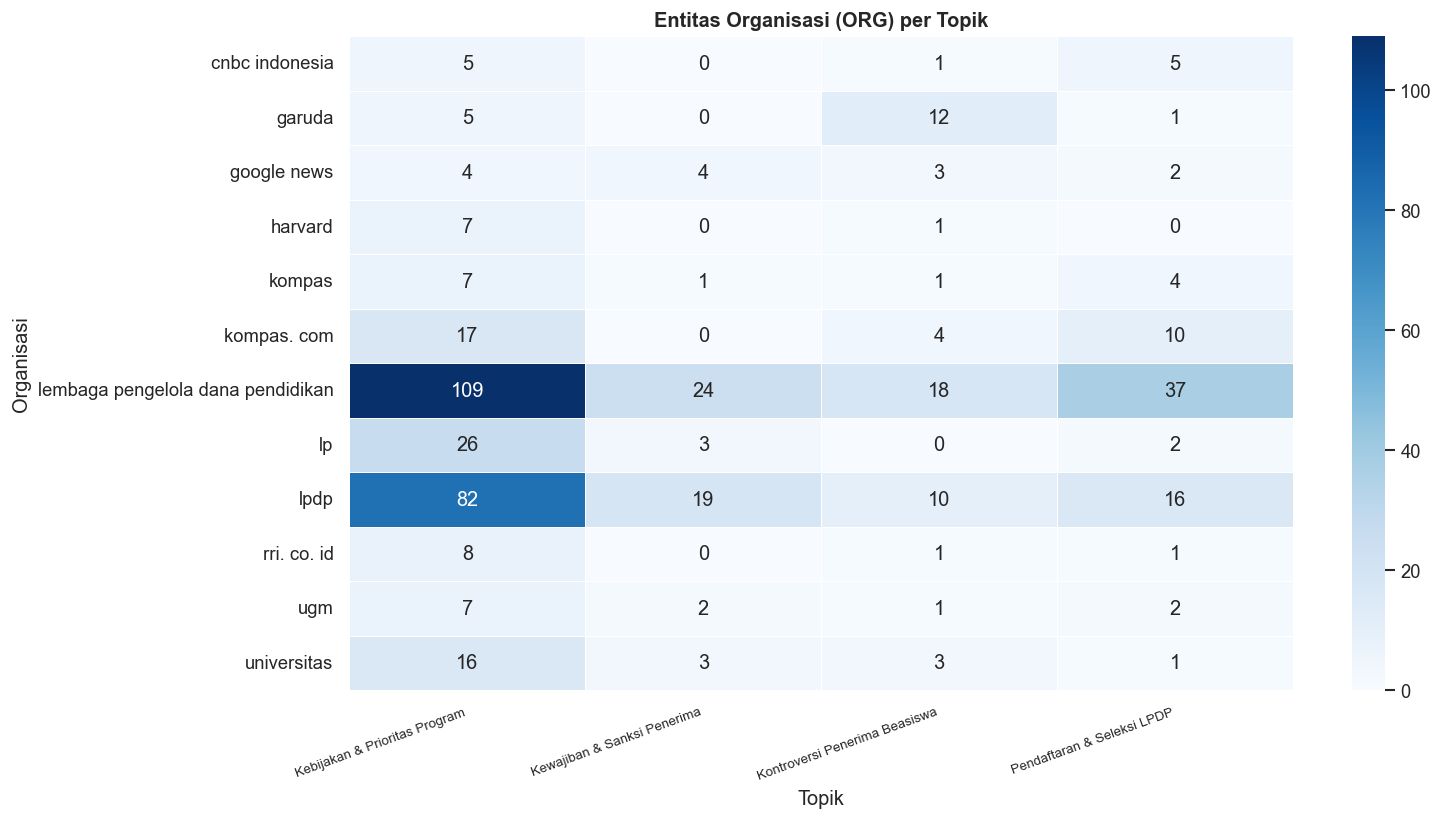

💾 Disimpan: output_ner_visualisasi/ner_heatmap_ORG_per_topik.png


In [14]:
if 'ORG' in df_ner_filtered['entity_type'].values:
    top_orgs = (
        df_ner_filtered[df_ner_filtered['entity_type'] == 'ORG']
        .groupby('entity')['doc_id'].nunique()
        .sort_values(ascending=False)
        .head(12).index.tolist()
    )

    heat_topic = (
        df_ner_filtered[
            (df_ner_filtered['entity_type'] == 'ORG') &
            (df_ner_filtered['entity'].isin(top_orgs)) &
            (df_ner_filtered['topic_label'].notna())
        ]
        .groupby(['entity', 'topic_label'])['doc_id'].nunique()
        .unstack(fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(13, 7))
    sns.heatmap(
        heat_topic, annot=True, fmt='d', cmap='Blues',
        linewidths=0.5, linecolor='white', ax=ax
    )
    ax.set_title('Entitas Organisasi (ORG) per Topik', fontsize=12, fontweight='bold')
    ax.set_xlabel('Topik')
    ax.set_ylabel('Organisasi')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
    plt.tight_layout()
    out_path = OUTPUT_DIR / 'ner_heatmap_ORG_per_topik.png'
    plt.savefig(out_path, bbox_inches='tight')
    plt.show()
    print(f"💾 Disimpan: {out_path}")

---
## 📊 Part 5: Analisis per Sumber Media

In [15]:
# Deteksi kolom sumber media
source_col = None
for c in ['Publisher', 'Sumber Media', 'source', 'publisher', 'Sumber', 'media']:
    if c in df.columns:
        source_col = c
        break

print(f"📰 Kolom sumber media: '{source_col}'")
print(df[source_col].value_counts().head(10))

📰 Kolom sumber media: 'Publisher'
Publisher
Kompas.com           101
LPDP                  86
Medcom.id             65
detikNews             31
Tempo.co              31
MetroTVNews.com       29
SINDOnews Edukasi     27
Suara.com             24
Kompas.id             24
CNBC Indonesia        23
Name: count, dtype: int64


<function matplotlib.pyplot.savefig(*args, **kwargs) -> 'None'>

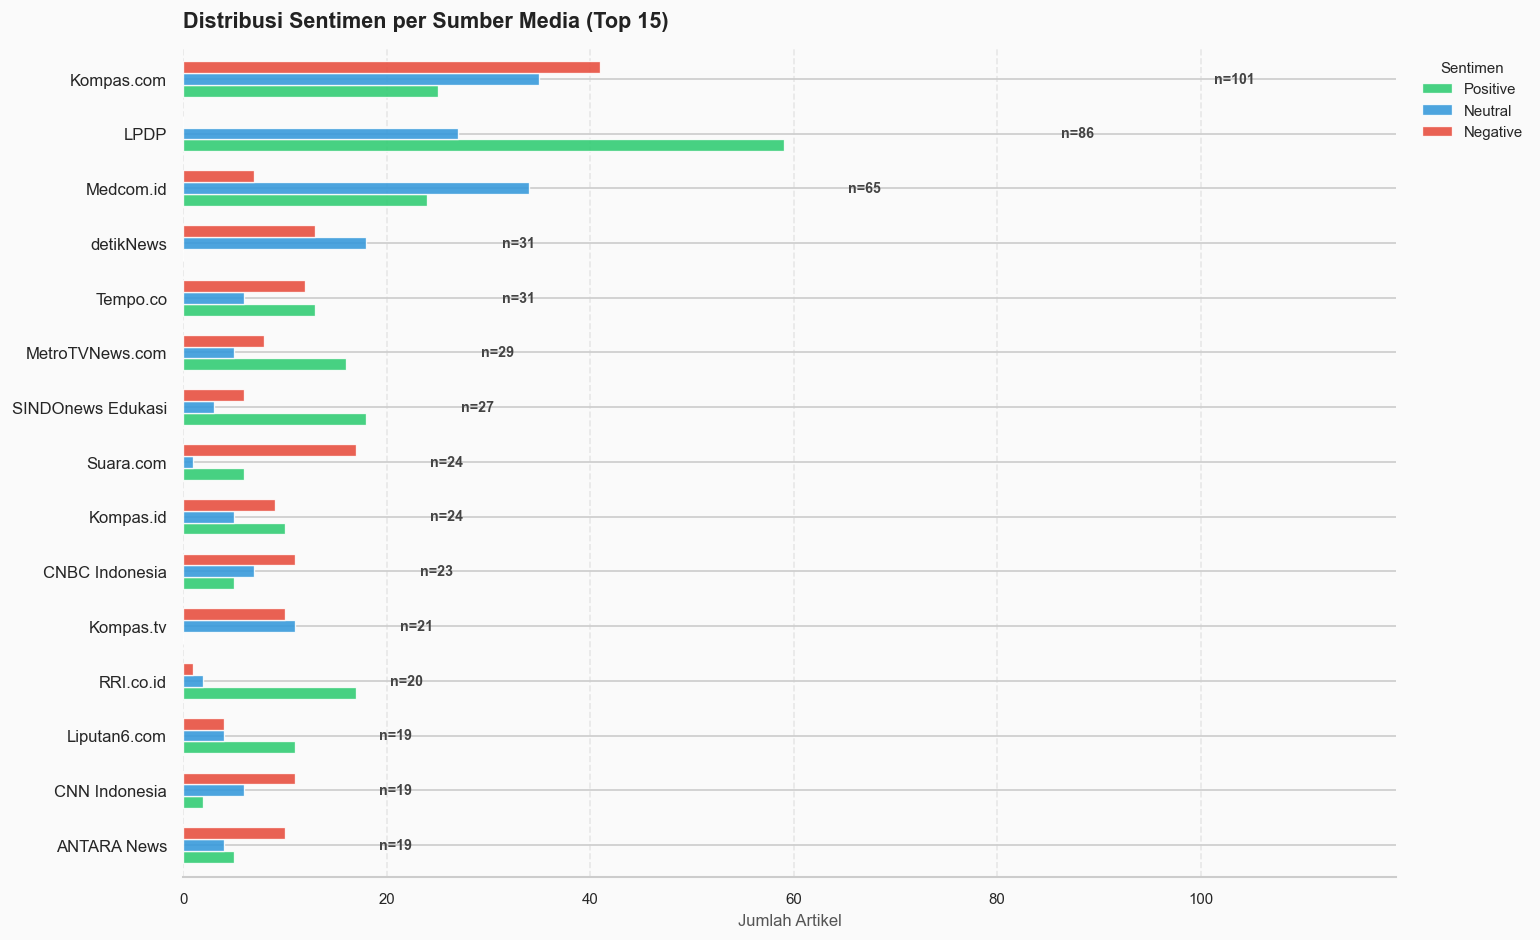

In [16]:
source_col = 'Publisher'  # Langsung hardcode, tidak perlu deteksi lagi

top_media = df[source_col].value_counts().head(15).index.tolist()
df_media = df[df[source_col].isin(top_media)]

media_pivot = (
    df_media.groupby([source_col, 'Sentiment'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['Positive', 'Neutral', 'Negative'], fill_value=0)
)

media_pivot['total'] = media_pivot.sum(axis=1)
media_pivot = media_pivot.sort_values('total', ascending=True).drop(columns='total')

fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

media_pivot.plot(
    kind='barh',
    color=[PALETTE.get(c, 'gray') for c in media_pivot.columns],
    ax=ax, edgecolor='white', linewidth=0.8, width=0.65, alpha=0.88
)

# Anotasi total di ujung bar
for i, (idx, row) in enumerate(media_pivot.iterrows()):
    total = row.sum()
    ax.text(
        total + 0.3, i,
        f'n={total}', va='center', ha='left',
        fontsize=8.5, color='#444', fontweight='bold'
    )

ax.set_title(
    'Distribusi Sentimen per Sumber Media (Top 15)',
    fontsize=13, fontweight='bold', color='#222', loc='left', pad=12
)
ax.set_xlabel('Jumlah Artikel', fontsize=10, color='#555')
ax.set_ylabel('')
ax.set_xlim(0, media_pivot.sum(axis=1).max() * 1.18)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=9)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.4, color='#ccc')
ax.set_axisbelow(True)
ax.legend(
    title='Sentimen', title_fontsize=9,
    bbox_to_anchor=(1.01, 1), loc='upper left',
    frameon=False, fontsize=9
)

plt.tight_layout()
out_path = OUTPUT_DIR / 'sentiment_per_sumber_media.png'
plt.savefig

---
## 📊 Part 6: Ringkasan Analisis Komprehensif

In [17]:
print("=" * 70)
print("📋 RINGKASAN ANALISIS — DATASET ARTIKEL LPDP")
print("=" * 70)

print(f"\n📦 Total Artikel   : {len(df)}")
print(f"   Artikel dengan topik  : {df['topic_label'].notna().sum()} ({df['topic_label'].notna().mean()*100:.1f}%)")

print("\n📊 Distribusi Sentimen:")
for s, cnt in df['Sentiment'].value_counts().items():
    print(f"   {s:<12}: {cnt:>4} artikel ({cnt/len(df)*100:.1f}%)")

print("\n📌 Distribusi Topik:")
for t, cnt in df['topic_label'].value_counts().items():
    print(f"   {t:<45}: {cnt:>4} artikel ({cnt/len(df_valid_topic)*100:.1f}%)")

print(f"\n🏷️  Hasil NER:")
print(f"   Total entitas ditemukan      : {len(df_ner)}")
print(f"   Entitas (score ≥ 0.85)       : {len(df_ner_filtered)}")
print(f"   Artikel dengan ≥1 entitas    : {df_ner_filtered['doc_id'].nunique()}")
print(f"   Rata-rata entitas/artikel    : {len(df_ner_filtered) / df_ner_filtered['doc_id'].nunique():.1f}")

print("\n   Tipe entitas ditemukan:")
for etype, cnt in df_ner_filtered['entity_type'].value_counts().items():
    print(f"   {etype:<8}: {cnt:>5} entitas")

if 'ORG' in df_ner_filtered['entity_type'].values:
    top_org = (
        df_ner_filtered[df_ner_filtered['entity_type'] == 'ORG']
        .groupby('entity')['doc_id'].nunique()
        .sort_values(ascending=False)
        .head(5)
    )
    print(f"\n   Top 5 Organisasi (ORG):")
    for ent, cnt in top_org.items():
        print(f"   {ent:<35}: {cnt} artikel")

if 'PER' in df_ner_filtered['entity_type'].values:
    top_per = (
        df_ner_filtered[df_ner_filtered['entity_type'] == 'PER']
        .groupby('entity')['doc_id'].nunique()
        .sort_values(ascending=False)
        .head(5)
    )
    print(f"\n   Top 5 Tokoh (PER):")
    for ent, cnt in top_per.items():
        print(f"   {ent:<35}: {cnt} artikel")

print("\n📁 File Output:")
for f_out in sorted(OUTPUT_DIR.iterdir()):
    size_kb = f_out.stat().st_size / 1024
    print(f"   {f_out.name:<50} ({size_kb:.1f} KB)")

print("=" * 70)
print("✅ Phase 6 selesai!")

📋 RINGKASAN ANALISIS — DATASET ARTIKEL LPDP

📦 Total Artikel   : 1038
   Artikel dengan topik  : 937 (90.3%)

📊 Distribusi Sentimen:
   Positive    :  385 artikel (37.1%)
   Neutral     :  342 artikel (32.9%)
   Negative    :  311 artikel (30.0%)

📌 Distribusi Topik:
   Kebijakan & Prioritas Program                :  553 artikel (59.0%)
   Kewajiban & Sanksi Penerima                  :  147 artikel (15.7%)
   Pendaftaran & Seleksi LPDP                   :  140 artikel (14.9%)
   Kontroversi Penerima Beasiswa                :   97 artikel (10.4%)

🏷️  Hasil NER:
   Total entitas ditemukan      : 32202
   Entitas (score ≥ 0.85)       : 6859
   Artikel dengan ≥1 entitas    : 633
   Rata-rata entitas/artikel    : 10.8

   Tipe entitas ditemukan:
   PER     :  2094 entitas
   ORG     :  1342 entitas
   GPE     :  1011 entitas
   DAT     :   790 entitas
   CRD     :   737 entitas
   NOR     :   435 entitas
   MON     :   157 entitas
   QTY     :    57 entitas
   EVT     :    52 entitas
   OR

---

## 📝 Catatan Lanjutan

### Output Phase 6 → Input Phase Berikutnya

| File | Digunakan Untuk |
|------|----------------|
| `output_ner_visualisasi/ner_results.csv` | Analisis entitas lanjutan, laporan akhir |
| `output_ner_visualisasi/ner_entities_summary.xlsx` | Tabel hasil presentasi |
| `output_ner_visualisasi/*.png` | Visualisasi untuk laporan & slide |

### Model NER Alternatif (jika ingin akurasi lebih tinggi)
| Model | Catatan |
|---|---|
| `cahya/bert-base-indonesian-NER` | Default notebook ini — ringan, cepat |
| `indobenchmark/indobert-large-p2` | Lebih besar, perlu GPU |
| `w11wo/bert-base-indonesian-NER` | Alternatif fine-tuned NER |

> 💡 **Tips**: Jika model NER menghasilkan terlalu banyak False Positive, naikkan threshold `score >= 0.85` menjadi `0.90` di sel 1.3.